In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License"); { display-mode: "form" }
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Producing data for synthetic regression

In [1]:
import os
import sys
from jax import config
import haiku as hk
import jax
from jax import numpy as jnp
import numpy as onp
import time
import tqdm
import functools
sys.path.append("../")
from utils import models
from utils import losses
from matplotlib import pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
# tpu_ip = "10.0.0.2"
# config.FLAGS.jax_xla_backend = "tpu_driver"
# config.FLAGS.jax_backend_target = "grpc://{}:8470".format(tpu_ip)

In [2]:
net_fn = models.make_mlp_regression(None, output_dim=1, layer_dims=[50])
net = hk.transform_with_state(net_fn)
net_apply = net.apply
net_apply = jax.default_matmul_precision("tensorfloat32")(
  net_apply)

In [3]:
x = jnp.concatenate([jnp.linspace(a, b, 40) for a, b in zip([-10, 6, 14], [-6, 10, 18])])
x_ = jnp.linspace(-14, 22, 120)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [4]:
def featurize(x):
    return jnp.concatenate([x[:, None], x[:, None]**2], axis=1)

f = featurize(x)
f_ = featurize(x_)

In [5]:
params, net_state = net.init(jax.random.PRNGKey(0), (f, None), True)

In [6]:
std = 0.1
normal_key = jax.random.PRNGKey(22)

num_leaves = len(jax.tree.leaves(params))
normal_keys = list(jax.random.split(normal_key, num_leaves))
treedef = jax.tree.structure(params)
normal_keys = jax.tree.unflatten(treedef, normal_keys)
params = jax.tree_map(lambda p, key: jax.random.normal(key, p.shape) * std,
                           params, normal_keys)

/tmp/ipykernel_3478658/3518073179.py:8: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  params = jax.tree_map(lambda p, key: jax.random.normal(key, p.shape) * std,


In [7]:
noise_key = jax.random.PRNGKey(0)
noise_std = 0.02

y, _ = net_apply(params, net_state, None, (f, None), False)
y_, _ = net_apply(params, net_state, None, (f_, None), False)
y += jax.random.normal(noise_key, y.shape) * noise_std

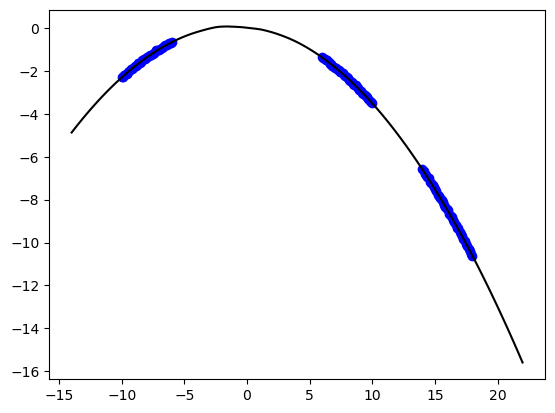

In [8]:
plt.plot(x, y, "bo")
plt.plot(x_, y_, "-k")

In [9]:
data = onp.savez(
    "synth_reg_data.npz",
    x_=onp.asarray(x_),
    y_=onp.asarray(y_),
    f_=onp.asarray(f_),
    x=onp.asarray(x),
    y=onp.asarray(y),
    f=onp.asarray(f)
)

In [10]:
log_prior_fn, log_prior_diff_fn = (
    losses.make_gaussian_log_prior(weight_decay=0.1, temperature=1))